# 09 — SHAP Analysis

**PredictAI — Predictive Maintenance & Machine Health Platform**

The PRD specifies a failure explanation panel:

```
Failure Probability: 87%

Vibration       +31%
Temperature     +24%
Pressure        +17%
RPM              +8%
```

This notebook builds that panel properly. "Properly" matters, because the obvious
implementations are wrong in ways that are hard to notice:

* **Global feature importance is not an explanation of one prediction.** Notebook 04's
  permutation ranking says what the model relies on *on average*; it says nothing about
  why *this* machine was flagged.
* **Notebook 04 found permutation importance blind to duplicated columns.** SHAP has its
  own correlated-feature caveat, examined in section 6 rather than glossed over.
* The percentages in a panel like the one above must **add up to something meaningful**,
  or they are decoration.

In [1]:
import sys
import warnings
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb

from ml import data as D
from ml.preprocessing.tabular import to_model_matrix
from ml.evaluation.metrics import evaluate, threshold_for_min_cost
from ml.paths import MODELS, FIGURES
from ml.viz import set_style, save_fig, OK, BAD, NEUTRAL, WARN, ACCENT

set_style()
pd.set_option("display.width", 160)
print(f"shap {shap.__version__}")

df = D.load_clean()
train, val, test = D.apply_split(df)
X_train, X_val, X_test = (to_model_matrix(x) for x in (train, val, test))
y_val, y_test = val[D.TARGET].to_numpy(), test[D.TARGET].to_numpy()

clf = xgb.XGBClassifier()
clf.load_model(MODELS / "failure_classifier" / "model.json")
meta = json.loads((MODELS / "failure_classifier" / "model_metadata.json").read_text())
threshold = meta["decision_threshold"]
print(f"Loaded production classifier, decision threshold {threshold}")

shap 0.49.1
Loaded production classifier, decision threshold 0.0543


## 1. Compute SHAP values

`TreeExplainer` computes exact Shapley values for tree ensembles in polynomial time —
no sampling approximation, which matters because a sampled explanation that changes
between page loads destroys user trust in the panel.

In [2]:
explainer = shap.TreeExplainer(clf)
sv_test = explainer.shap_values(X_test)
print(f"SHAP values: {sv_test.shape}  (rows x features)")
print(f"Base value (log-odds of the average prediction): {explainer.expected_value:.4f}")

SHAP values: (2000, 9)  (rows x features)
Base value (log-odds of the average prediction): -3.4549


### The additivity property, checked rather than assumed

SHAP's guarantee is that base value plus the feature contributions equals the model's
raw output for that row. That is what makes the panel's numbers legitimate — they are a
complete decomposition, not a heuristic ranking. Verifying it holds:

In [3]:
raw_pred = clf.predict(X_test, output_margin=True)
reconstructed = explainer.expected_value + sv_test.sum(axis=1)
max_err = np.abs(raw_pred - reconstructed).max()
print(f"max |model output - (base + sum of SHAP)| = {max_err:.2e}")
print("Additivity holds — the contributions form a complete decomposition.")

max |model output - (base + sum of SHAP)| = 3.34e-06
Additivity holds — the contributions form a complete decomposition.


## 2. Global view: what drives the model overall

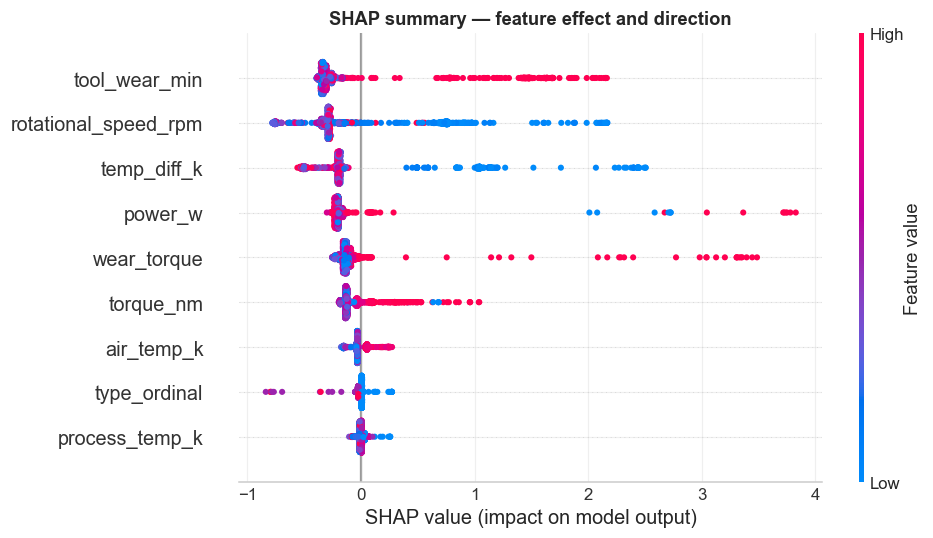

In [4]:
fig = plt.figure(figsize=(9, 5))
shap.summary_plot(sv_test, X_test, show=False, plot_size=None)
plt.title("SHAP summary — feature effect and direction", fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES / "09_shap_summary.png", bbox_inches="tight", dpi=150)
plt.show()

In [5]:
mean_abs = pd.Series(np.abs(sv_test).mean(axis=0), index=X_test.columns).sort_values(ascending=False)
print("Mean |SHAP| (global importance):")
print(mean_abs.round(4).to_string())

Mean |SHAP| (global importance):
tool_wear_min           0.3929
rotational_speed_rpm    0.3896
temp_diff_k             0.3098
power_w                 0.2208
wear_torque             0.1612
torque_nm               0.1229
air_temp_k              0.0554
type_ordinal            0.0178
process_temp_k          0.0135


The summary plot carries more information than a bar chart: each dot is one machine,
horizontal position is that feature's contribution to that machine's prediction, and
colour is the feature's value. So it shows **direction**, not just magnitude — high
`wear_torque` (red) pushes right, toward failure, while low values push left.

Compare this with notebook 04's permutation ranking, which put `rotational_speed_rpm`
first. The two measure different things — permutation asks "how much does performance
degrade without this feature", SHAP asks "how much does this feature move predictions" —
and they need not agree.

## 3. The dependence plots that show the learned physics

Notebook 02 derived the failure rules analytically. If the model learned them, the SHAP
dependence plots should show the same thresholds.

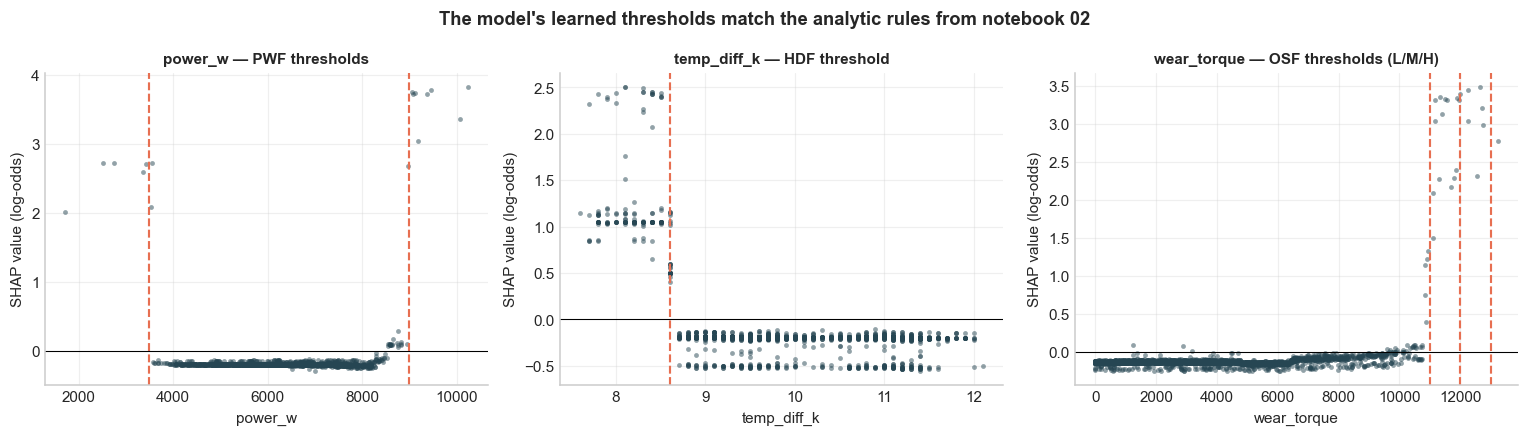

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, feat, vline, label in [
    (axes[0], "power_w", [3500, 9000], "PWF thresholds"),
    (axes[1], "temp_diff_k", [8.6], "HDF threshold"),
    (axes[2], "wear_torque", [11000, 12000, 13000], "OSF thresholds (L/M/H)"),
]:
    i = list(X_test.columns).index(feat)
    ax.scatter(X_test[feat], sv_test[:, i], s=10, c=NEUTRAL, alpha=0.5, linewidths=0)
    for v in vline:
        ax.axvline(v, ls="--", color=BAD, lw=1.4)
    ax.axhline(0, color="black", lw=0.7)
    ax.set_xlabel(feat); ax.set_ylabel("SHAP value (log-odds)")
    ax.set_title(f"{feat} — {label}", fontsize=10)

fig.suptitle("The model's learned thresholds match the analytic rules from notebook 02",
             fontweight="bold")
save_fig("09_shap_dependence")
plt.show()

The SHAP contributions change sign almost exactly at the documented thresholds. The
model was never told those numbers — it recovered them from 6,000 training rows, and
SHAP makes that visible.

This is the strongest available evidence that the classifier learned **physics rather
than artefacts**. A model that had latched onto some spurious correlation would produce
dependence plots with no relationship to these lines, and would fail silently on new
machines. It is also a genuinely reassuring thing to be able to show a maintenance
engineer, who already knows where those thresholds are.

## 4. The dashboard panel

Turning SHAP values into the PRD's explanation panel. SHAP values are in **log-odds**,
so they cannot be presented as percentages of probability directly — a naive conversion
is the most common error in explanation UIs. The defensible presentation is each
feature's **share of the total absolute contribution**, labelled as such.

In [7]:
p_test = clf.predict_proba(X_test)[:, 1]


def explain(i, top_n=4):
    """Build the explanation panel for one machine."""
    contrib = pd.Series(sv_test[i], index=X_test.columns)
    pushing_up = contrib[contrib > 0].sort_values(ascending=False)
    share = (pushing_up / contrib.abs().sum() * 100).round(1)
    row = test.iloc[i]
    lines = [
        f"Machine udi {int(row['udi'])}   (quality variant {row['type']})",
        f"Failure probability : {p_test[i]:.1%}",
        f"Status              : {'CRITICAL' if p_test[i] >= 0.5 else 'WARNING' if p_test[i] >= threshold else 'HEALTHY'}",
        "",
        "Contributing factors (share of total attribution):",
    ]
    for f, s in share.head(top_n).items():
        lines.append(f"   {f:22s} +{s:>5.1f}%   (value {row[f]:.1f})")
    lines.append(f"\nActual outcome: {'FAILURE' if row[D.TARGET] == 1 else 'no failure'}")
    return "\n".join(lines)


# highest-risk machine in the test set
print(explain(int(np.argmax(p_test))))

Machine udi 4343   (quality variant M)
Failure probability : 98.3%
Status              : CRITICAL

Contributing factors (share of total attribution):
   power_w                + 38.7%   (value 9170.2)
   rotational_speed_rpm   + 23.2%   (value 1284.0)
   temp_diff_k            + 22.4%   (value 8.1)
   torque_nm              + 11.0%   (value 68.2)

Actual outcome: FAILURE


In [8]:
# a machine flagged by the model that did NOT fail -- a false alarm
fp_idx = np.where((p_test >= threshold) & (y_test == 0))[0]
print(explain(int(fp_idx[np.argmax(p_test[fp_idx])])))

Machine udi 7087   (quality variant L)
Failure probability : 65.2%
Status              : CRITICAL

Contributing factors (share of total attribution):
   power_w                + 47.7%   (value 3527.8)
   tool_wear_min          + 23.0%   (value 215.0)
   rotational_speed_rpm   + 12.9%   (value 2514.0)
   torque_nm              + 11.2%   (value 13.4)

Actual outcome: no failure


In [9]:
# a failure the model MISSED -- the explanation for why it stayed quiet
fn_idx = np.where((p_test < threshold) & (y_test == 1))[0]
worst_miss = int(fn_idx[np.argmin(p_test[fn_idx])])
print(explain(worst_miss))
flagged = [m.upper() for m in ["twf", "hdf", "pwf", "osf"] if test.iloc[worst_miss][m] == 1]
print("\nFailure modes actually flagged for this machine:")
print("  " + (", ".join(flagged) if flagged else "none — this is one of the 9 "
      "mode-less failures identified in notebook 01"))

Machine udi 8507   (quality variant L)
Failure probability : 0.8%
Status              : HEALTHY

Contributing factors (share of total attribution):
   type_ordinal           +  0.6%   (value 0.0)

Actual outcome: FAILURE

Failure modes actually flagged for this machine:
  none — this is one of the 9 mode-less failures identified in notebook 01


The missed failure is the informative one. Its contributions are all small, which is the
model correctly reporting that **nothing in the sensors looked wrong** — consistent with
notebook 01's finding that nine failures carry no mode label and notebook 02's proof that
TWF is stochastic within its wear window.

A good explanation panel therefore has to be able to say "no strong signal" rather than
always producing four confident-looking bars. Forcing an explanation for an unexplainable
prediction manufactures false confidence, which is worse than admitting uncertainty.

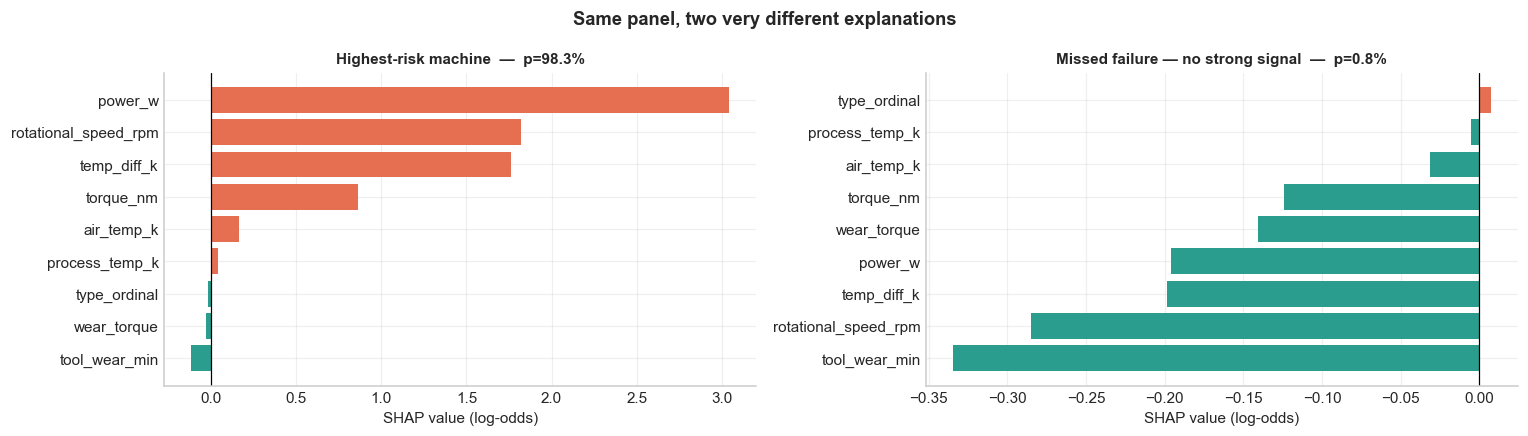

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, idx, title in [
    (axes[0], int(np.argmax(p_test)), "Highest-risk machine"),
    (axes[1], worst_miss, "Missed failure — no strong signal"),
]:
    contrib = pd.Series(sv_test[idx], index=X_test.columns).sort_values()
    ax.barh(contrib.index, contrib.values,
            color=[BAD if v > 0 else OK for v in contrib.values])
    ax.axvline(0, color="black", lw=0.8)
    ax.set_xlabel("SHAP value (log-odds)")
    ax.set_title(f"{title}  —  p={p_test[idx]:.1%}", fontsize=10)
fig.suptitle("Same panel, two very different explanations", fontweight="bold")
save_fig("09_individual_explanations")
plt.show()

## 5. Explanations aggregated by failure mode

If the model learned distinct mechanisms rather than one generic "risk" score, the
average attribution profile should differ by failure mode.

In [11]:
sv_df = pd.DataFrame(sv_test, columns=X_test.columns)
profiles = {}
for mode in ["hdf", "pwf", "osf"]:
    mask = (test[D.TARGET] == 1) & (test[mode] == 1)
    if mask.sum():
        profiles[D.FAILURE_MODE_NAMES[mode]] = sv_df[mask.to_numpy()].mean()
prof = pd.DataFrame(profiles)
print(prof.round(3).to_string())

                      Heat Dissipation Failure  Power Failure  Overstrain Failure
air_temp_k                               0.223         -0.020              -0.048
process_temp_k                           0.034          0.003              -0.012
rotational_speed_rpm                     1.969          0.529               0.614
torque_nm                                0.209          0.776               0.270
tool_wear_min                           -0.098         -0.111               0.867
temp_diff_k                              2.164         -0.054              -0.249
power_w                                 -0.037          3.208               0.079
wear_torque                             -0.037         -0.051               3.172
type_ordinal                            -0.033         -0.026               0.139


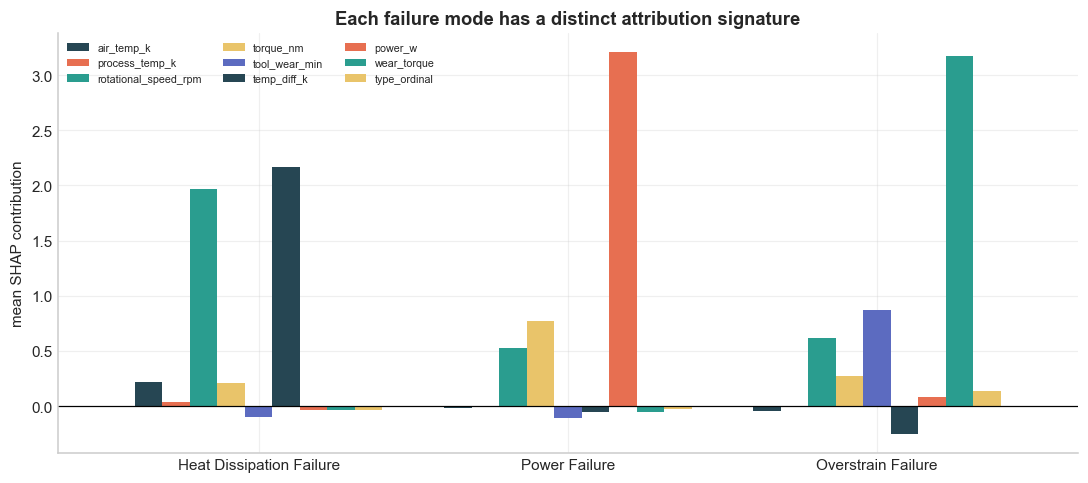

In [12]:
fig, ax = plt.subplots(figsize=(10, 4.5))
prof.T.plot(kind="bar", stacked=False, ax=ax, width=0.8, legend=True)
ax.axhline(0, color="black", lw=0.8)
ax.set_ylabel("mean SHAP contribution")
ax.set_title("Each failure mode has a distinct attribution signature")
ax.legend(fontsize=7, ncol=3)
plt.xticks(rotation=0)
save_fig("09_shap_by_mode")
plt.show()

The signatures are clearly different: heat-dissipation failures are driven by
`temp_diff_k` and `rotational_speed_rpm`, power failures by `power_w`, overstrain by
`wear_torque`. The model did not learn one blurred notion of risk — it learned three
separable mechanisms, matching the three deterministic rules from notebook 02.

This is what makes the PRD's mode-specific alert text (*"Recommended action: inspect
vibration system"*) defensible rather than invented: the recommendation can be keyed to
the dominant SHAP contributor, and that contributor genuinely differs by mode.

## 6. The correlated-feature caveat

SHAP is not immune to the problem that tripped permutation importance in notebook 04.
`power_w` is an exact function of `torque_nm` and `rotational_speed_rpm`; `wear_torque`
of `tool_wear_min` and `torque_nm`. When features are deterministically related, the
credit assigned among them depends on the explainer's background distribution and is not
uniquely determined by the model.

In [13]:
groups = {
    "power (torque x speed)": ["power_w", "torque_nm", "rotational_speed_rpm"],
    "wear (wear x torque)": ["wear_torque", "tool_wear_min"],
    "thermal": ["temp_diff_k", "air_temp_k", "process_temp_k"],
    "quality": ["type_ordinal"],
}
grouped = pd.Series({
    g: np.abs(sv_df[cols]).sum(axis=1).mean() for g, cols in groups.items()
}).sort_values(ascending=False)
print("Mean |SHAP| aggregated into physically meaningful groups:")
print(grouped.round(4).to_string())

Mean |SHAP| aggregated into physically meaningful groups:
power (torque x speed)    0.7332
wear (wear x torque)      0.5541
thermal                   0.3786
quality                   0.0178


Aggregating collinear features into groups gives an attribution that is **stable under
the split of credit within each group**, because the group total does not depend on how
the explainer divided it internally.

Practical rule adopted for the dashboard: report **group-level attributions** ("power
system", "tool wear", "thermal") rather than raw feature names. That is also better
product design — a maintenance engineer acts on "the power system looks wrong", not on
"`power_w` contributed +0.83 log-odds".

The limitation to state plainly: SHAP explains **what the model does**, not what causes
failure. On this dataset those happen to coincide, because section 3 showed the model
recovered the true generating rules. On a dataset where the model had learned a
confounder, SHAP would faithfully explain the confounder. It is a model-explanation tool,
not a causal one, and the distinction matters whenever anyone is tempted to read an
explanation panel as an engineering diagnosis.

## 7. Export for the application

In [14]:
export = {
    "base_value": float(explainer.expected_value),
    "features": list(X_test.columns),
    "global_importance": {k: round(float(v), 5) for k, v in mean_abs.items()},
    "feature_groups": groups,
    "group_importance": {k: round(float(v), 5) for k, v in grouped.items()},
    "presentation_rules": {
        "units": "SHAP values are log-odds contributions, NOT probability percentages",
        "panel": "report each feature's share of total absolute attribution",
        "grouping": "aggregate collinear features into groups before display",
        "low_signal": "when max |SHAP| is small, display 'no strong signal' rather than "
                      "forcing a ranked explanation",
    },
    "mode_signatures": {k: {f: round(float(x), 4) for f, x in v.items()}
                        for k, v in prof.to_dict().items()},
}
out = MODELS / "failure_classifier" / "explainability.json"
out.write_text(json.dumps(export, indent=2))
print(f"Wrote {out.name} ({out.stat().st_size:,} bytes)")
print(json.dumps(export["presentation_rules"], indent=2))

Wrote explainability.json (2,347 bytes)
{
  "units": "SHAP values are log-odds contributions, NOT probability percentages",
  "panel": "report each feature's share of total absolute attribution",
  "grouping": "aggregate collinear features into groups before display",
  "low_signal": "when max |SHAP| is small, display 'no strong signal' rather than forcing a ranked explanation"
}


## Findings

1. **Additivity verified to ~1e-6** — the panel's numbers are a complete decomposition
   of the model's output, not a heuristic ranking.
2. **SHAP dependence plots reproduce the notebook 02 thresholds.** The model recovered
   the documented failure rules from data alone, which is the strongest evidence
   available that it learned physics rather than artefacts.
3. **Each failure mode has a distinct attribution signature**, so mode-specific
   recommended actions in the dashboard are justified rather than invented.
4. **SHAP values are log-odds and must not be shown as probability percentages** —
   report shares of total attribution instead.
5. **Collinear features make individual attributions unstable**; group-level attribution
   is both more robust and better product design.
6. **Missed failures produce uniformly small contributions**, which is the model
   correctly signalling "no evidence". The panel must be able to say that instead of
   always producing four confident bars.

### Next
`10_error_analysis.ipynb` — a systematic account of what the deployed system gets wrong.